## Multilayer perceptron using sequential embeddings to predict log binding affinity:

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import KFold, ParameterGrid
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import mean_absolute_error, r2_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset
from transformers import AutoTokenizer, AutoModel, EsmTokenizer, EsmModel
from tqdm import tqdm

2025-02-10 12:39:36.486546: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-02-10 12:39:41.432937: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: libnvinfer.so.7: cannot open shared object file: No such file or directory; LD_LIBRARY_PATH: /local/java/cuda-11.6.0/lib64/:/local/java/cudnn-linux-x86_64-8.5.0.96_cuda11-archive/lib/:/local/java/cuda-12.6.2/lib64/:/local/java/cudnn-linux-x86_64-9.5.1.17_cuda12-archive/lib/
2025-02-10 12:39:41.433914: W tensorflow/compiler/xla/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer_plugin.so.7'; dlerror: libnvinfer_plugin.so.7: cannot open shared objec

## Load and preprocess data - generate embeddings (end-to-end model):

In [2]:
# Preprocess the data
data = pd.read_csv('/dcs/22/u2243582/cs310/feature_extraction/refined-set-csv.csv')
data = data[~data['Protein_FASTA'].str.contains('X')] # remove complexes with ambiguous char in FASTA string
toDrop = ['4yx4', '1laf', '4buq', '1k22', '1hmt', '1utn', '4rux', '1bty']
data = data[~data['PDB_Code'].isin(toDrop)]
data = data.reset_index()
display(data)

,index,PDB_Code,Protein_FASTA,Ligand_SMILES,Binding_data,Log_binding
0,0,6ugp,HWGYGKHNGPEHWHKDFPIAKGERQSPVDIDTHTAKYDPSLKPLSV...,O=C1Nc2c(Cl)cccc2S(=O)(=O)N1,Ki=685.5nM,6.16
1,1,4rdn,ENLYFQHMKHGRVFIIKSYSEDDIHRSIKYNIWCSTEHGNKRLDAA...,CNc1ncnc2c1ncn2[C@@H]1O[C@H](CO)[C@@H](O)[C@H]1O,Kd=1.2uM,5.92
2,2,4mo4,PRYLGLMSGTSLDGMDIVLIEQGDRTTLLASHYLPMPAGLREDILA...,C[P@@](=O)([O-])O[P@@](=O)([O-])OC[C@H]1O[C@@H...,Kd=0.06mM,4.22
3,3,3s0b,MTIEELKTRLHTEQSVCKTETGIDQQKANDVIEGNIDVEDKKVQLY...,c1ccc(Nc2cccc3ccccc23)cc1,Kd=0.32uM,6.49
4,4,6r1d,ASIFRCRQCGQTISRRDWLLPMGGDHEHVVFNPAGMIFRVWCFSLA...,O=C1C[C@H](NC(=O)OCc2ccccc2)C(=O)N1,Ki=4uM,5.40
...,...,...,...,...,...,...
5054,5244,6p3t,VTLCSPTEDDWPGMFLLAAASFTDFIGPESATAWRTLVPTDGAVVV...,CN(c1ccc2ccccc2c1)S(=O)(=O)c1ccc2[nH]c(=O)c(=O...,Ki=0.048uM,7.32
5055,5245,1tx7,IVGGYTCGANTVPYQVSLNSGYHFCGGSLINSQWVVSAAHCYKSGI...,C[P@@](=O)([O-])c1ccc(C(N)=[NH2+])cc1,Ki=25uM,4.60
5056,5246,3ta1,MKMVVAVIRPEKLECVKKALEERGFVGMTVTEVKGRGEQKGIRLQF...,Nc1ncnc2c1ncn2[C@@H]1O[C@H](CO[P@@](=O)([O-])O...,Kd=568uM,3.25
5057,5247,6r0v,VLAPGASIFRCRQCGQTISRRDWLLPMGGDHEHVVFNPAGMIFRVW...,O=C1C[C@H](NC(=O)c2cc([N+](=O)[O-])ccc2C(=O)[O...,Ki=11uM,4.96


In [3]:
# To generate embeddings, need list of FASTA and list of SMILES
protein_fastas = data['Protein_FASTA'].tolist()
ligand_SMILES = data['Ligand_SMILES'].tolist()

In [4]:
# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
# Load protein embedding model (ESM2)
esm_model_name = "facebook/esm2_t12_35M_UR50D"
esm_tokenizer = EsmTokenizer.from_pretrained(esm_model_name)
esm_model = EsmModel.from_pretrained(esm_model_name).to(device)

# Load ligand embedding model (ChemBERTa)
chemberta_model_name = "DeepChem/ChemBERTa-10M-MTR"
chemberta_tokenizer = AutoTokenizer.from_pretrained(chemberta_model_name)
chemberta_model = AutoModel.from_pretrained(chemberta_model_name).to(device)

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t12_35M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of RobertaModel were not initialized from the model checkpoint at DeepChem/ChemBERTa-10M-MTR and are newly initialized: ['roberta.pooler.dense.bias', 'roberta.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
# Batch processing for protein sequences
def generate_protein_embeddings(fasta_sequences, batch_size=4, max_length=1024):
    esm_model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(fasta_sequences), batch_size), desc="Processing Protein Batches"):
            batch = fasta_sequences[i:i + batch_size]
            inputs = esm_tokenizer(batch, return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
            outputs = esm_model(**inputs)
            # Extract the last layer and apply mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            # Clear GPU memory after processing the batch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return np.concatenate(all_embeddings, axis=0)

# Batch processing for ligand SMILES strings
def generate_ligand_embeddings(smiles_list, batch_size=4):
    chemberta_model.eval()
    all_embeddings = []
    
    with torch.no_grad():
        for i in tqdm(range(0, len(smiles_list), batch_size), desc="Processing Ligand Batches"):
            batch = smiles_list[i:i + batch_size]
            inputs = chemberta_tokenizer(batch, return_tensors="pt", padding=True, truncation=True).to(device)
            outputs = chemberta_model(**inputs)
            # Extract the last layer and apply mean pooling
            embeddings = outputs.last_hidden_state.mean(dim=1).cpu().numpy()
            all_embeddings.append(embeddings)
            # Clear GPU memory after processing the batch
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
    
    return np.concatenate(all_embeddings, axis=0)

In [7]:
# Generate Embeddings
protein_embeddings = generate_protein_embeddings(protein_fastas)
print(f"\nProtein embeddings shape: {protein_embeddings.shape}")

ligand_embeddings = generate_ligand_embeddings(ligand_SMILES)
print(f"Ligand embeddings shape: {ligand_embeddings.shape}")

Processing Protein Batches: 100%|██████████| 1265/1265 [01:30<00:00, 14.03it/s]



Protein embeddings shape: (5059, 480)


Processing Ligand Batches: 100%|██████████| 1265/1265 [00:03<00:00, 323.42it/s]

Ligand embeddings shape: (5059, 384)


In [8]:
# Single array of embeddings data
embeddings = np.concatenate((protein_embeddings, ligand_embeddings), axis=1) # (5059, 864)

In [9]:
# Scale the data so one type of embedding (protein or ligand) doesn’t dominate the model due to larger magnitude values.
    # Again not applying PCA ... should I investigate what happens when applying PCA?
scaler = StandardScaler()
scaler.fit(embeddings)
X = scaler.transform(embeddings)

y = data['Log_binding'].to_numpy()

In [10]:
# Convert to PyTorch tensors
X = torch.tensor(X, dtype=torch.float32)
y = torch.tensor(y, dtype=torch.float32)

## Defining the MLP model:

In [11]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate, num_hidden_layers=2):
        super(MLP, self).__init__()
        
        self.hidden_layers = nn.ModuleList()

        # First hidden layer
        self.hidden_layers.append(nn.Linear(input_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Second hidden layer
        self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
        self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
        
        # Third hidden layer (if num_hidden_layers == 3)
        if num_hidden_layers == 3:
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))
            
        # Third hidden layer (if num_hidden_layers == 4)
        if num_hidden_layers == 4:
            self.hidden_layers.append(nn.Linear(hidden_dim, hidden_dim))
            self.hidden_layers.append(nn.BatchNorm1d(hidden_dim))

        # Output layer
        self.output_layer = nn.Linear(hidden_dim, 1)

        # Dropout
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x):
        for i in range(0, len(self.hidden_layers), 2): # to skip the BatchNorm element
            x = torch.relu(self.hidden_layers[i+1](self.hidden_layers[i](x)))
            # Using ReLU activation function (common, helps prevent vanishing gradient)
            # Sigmoid outpus value between 0 - 1 so not useful for predicting affinity value
            # Tanh also outputs between -1 and 1
            # Leaky ReLU also exists for negative inputs, but all log affinity values btw 2 and 12
            x = self.dropout(x)

        x = self.output_layer(x)  # No activation for regression
        return x

## Defining the training function - uses early stopping

In [12]:
def train(model, train_loader, val_loader, criterion, optimizer, patience=10, epochs=50): # patience for early stopping over N epochs
    model.to(device)
    best_loss = float("inf")
    patience_counter = 0
    epoch_losses = []
    
    for epoch in range(epochs):
        model.train() # Forward pass through the neural network layers (with batch normalisation and dropout regularisation)
        train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad() # Clear the previous gradients (for proper calculations)
            y_pred = model(X_batch).squeeze()
            loss = criterion(y_pred, y_batch.squeeze()) # Calculate the loss
            loss.backward() # Compute the gradients (backpropagation)
            optimizer.step() # Update weights (by the optimzer object)
            train_loss += loss.item()

        avg_train_loss = train_loss / len(train_loader)
        epoch_losses.append(avg_train_loss)

        # ---- Validation Step ----
        model.eval() # Evaluation mode, changes behaviour of layers (dropout and batch normalization)
        val_loss = 0

        with torch.no_grad():
            for X_val_batch, y_val_batch in val_loader:
                X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
                y_val_pred = model(X_val_batch).squeeze()
                loss = criterion(y_val_pred, y_val_batch.squeeze())
                val_loss += loss.item()

        avg_val_loss = val_loss / len(val_loader)

        # ---- Early Stopping Check ----
        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"Early stopping after {epoch+1} epochs")
                break

    return epoch_losses  # Return loss curve for plotting

## Nested CV on embeddings features - 5 outer 3 inner folds

In [13]:
param_grid = {
    "hidden_dim": [512, 1024], # Neurons per hidden layer, more = more complex representations
    "dropout_rate": [0.1, 0.2, 0.3, 0.4],
    "learning_rate": [0.1, 0.01, 0.005, 0.001], # Step size at each iteration moving toward minimum of loss function - during optimisation
    "num_hidden_layers": [2, 3, 4]
    # batch size 16, 32, 62, 128 - smaller batches more updates but noisier gradients, larger require more memory
    # optimizer SGD basic optimzer, Adam adaptive learning rate
    # weight initialization: Xavier/Glorot Initialisation, He initialisation, Uniform/Normal distribution
    # number of epochs - under or overfitting
    # L1 (absolute val) or L2 (squared val) regularisation adds penalty to large weignts, prevent overfitting
}

# ---- Outer Loop ----
outer_kf = KFold(n_splits=5, shuffle=True, random_state=1)
all_loss_curves = []

results = [] # Store results

for fold, (train_idx, test_idx) in enumerate(outer_kf.split(X)):
    print(f"Outer Fold {fold+1}/5")
    
    random_params = [
    {key: random.choice(values) for key, values in param_grid.items()} 
    for _ in range(3)
    ]
    
    # print("random_params for this outer fold:", random_params)

    X_train_outer, X_test_outer = X[train_idx], X[test_idx]
    y_train_outer, y_test_outer = y[train_idx], y[test_idx]

    inner_kf = KFold(n_splits=3, shuffle=True, random_state=1)
    best_params = None
    best_val_loss = float("inf")
    
    # ---- Inner Loop: Hyperparameter Tuning ----
    for params in random_params:
        # print("Using hyperparams", params)
        
        val_losses = []

        for train_inner_idx, val_idx in inner_kf.split(X_train_outer):
            X_train_inner, X_val = X_train_outer[train_inner_idx], X_train_outer[val_idx]
            y_train_inner, y_val = y_train_outer[train_inner_idx], y_train_outer[val_idx]

            train_loader = DataLoader(TensorDataset(X_train_inner, y_train_inner), batch_size=32, shuffle=True)
            val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=32, shuffle=False)

            model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=params["hidden_dim"], 
                dropout_rate=params["dropout_rate"], 
                num_hidden_layers=params["num_hidden_layers"]).to(device)
            criterion = nn.MSELoss()
            optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=1e-5)

            epoch_losses = train(model, train_loader, val_loader, criterion, optimizer, epochs=50)
            val_losses.append(min(epoch_losses))

        mean_val_loss = np.mean(val_losses)

        if mean_val_loss < best_val_loss:
            best_val_loss = mean_val_loss
            best_params = params

    print(f"Best hyperparams for Fold {fold+1}: {best_params}")
    
    # ---- Train Final Model with Best Hyperparams ----
    train_loader = DataLoader(TensorDataset(X_train_outer, y_train_outer), batch_size=64, shuffle=True)
    test_loader = DataLoader(TensorDataset(X_test_outer, y_test_outer), batch_size=64, shuffle=False)

    model = MLP(input_dim=X_train_outer.shape[1], 
                hidden_dim=best_params["hidden_dim"], 
                dropout_rate=best_params["dropout_rate"], 
                num_hidden_layers=best_params["num_hidden_layers"]).to(device)
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=best_params["learning_rate"], weight_decay=1e-5)

    epoch_losses = train(model, train_loader, test_loader, criterion, optimizer, epochs=50)
    all_loss_curves.append(epoch_losses)
    
    # ---- Evaluate Model ----
    model.eval()
    y_pred_list, y_true_list = [], []

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch = X_batch.to(device)
            y_pred = model(X_batch).squeeze().cpu().numpy()
            y_true = y_batch.squeeze().cpu().numpy()

            y_pred_list.extend(y_pred)
            y_true_list.extend(y_true)

    pearson_corr, pearson_p = pearsonr(y_true_list, y_pred_list)
    spearman_corr, spearman_p = spearmanr(y_true_list, y_pred_list)
    mae = mean_absolute_error(y_true_list, y_pred_list)
    variance = np.var(np.array(y_true_list) - np.array(y_pred_list))
    r2 = r2_score(y_true_list, y_pred_list)

    results.append({"Fold": fold+1, "Pearson": pearson_corr, "Pearson p": pearson_p, "Spearman": spearman_corr, "Spearman p": spearman_p, "MAE": mae, "Variance": variance, "R2": r2})

Outer Fold 1/5
Early stopping after 26 epochs
Early stopping after 28 epochs
Early stopping after 18 epochs
Early stopping after 34 epochs
Early stopping after 32 epochs
Early stopping after 17 epochs
Early stopping after 27 epochs
Early stopping after 21 epochs
Best hyperparams for Fold 1: {'hidden_dim': 512, 'dropout_rate': 0.1, 'learning_rate': 0.005, 'num_hidden_layers': 2}
Early stopping after 39 epochs
Outer Fold 2/5
Early stopping after 31 epochs
Early stopping after 36 epochs
Early stopping after 50 epochs
Early stopping after 34 epochs
Early stopping after 36 epochs
Early stopping after 24 epochs
Early stopping after 31 epochs
Early stopping after 20 epochs
Early stopping after 26 epochs
Best hyperparams for Fold 2: {'hidden_dim': 512, 'dropout_rate': 0.4, 'learning_rate': 0.001, 'num_hidden_layers': 2}
Early stopping after 36 epochs
Outer Fold 3/5
Early stopping after 28 epochs
Early stopping after 19 epochs
Early stopping after 35 epochs
Early stopping after 20 epochs
Early 

In [14]:
print(results)

[{'Fold': 1, 'Pearson': 0.7442084990603048, 'Pearson p': 3.290857693658406e-179, 'Spearman': 0.7309444962678182, 'Spearman p': 8.6806162307012e-170, 'MAE': 1.0472852, 'Variance': 1.7919985, 'R2': 0.5143398420721278}, {'Fold': 2, 'Pearson': 0.7226634431590849, 'Pearson p': 3.4686492735209084e-164, 'Spearman': 0.7227871582538268, 'Spearman p': 2.870649950983851e-164, 'MAE': 1.1068323, 'Variance': 1.8963382, 'R2': 0.45340906044219487}, {'Fold': 3, 'Pearson': 0.7191133627051195, 'Pearson p': 7.576178149601575e-162, 'Spearman': 0.7181025599468206, 'Spearman p': 3.4585401266912196e-161, 'MAE': 1.0298867, 'Variance': 1.8273498, 'R2': 0.5072728576289538}, {'Fold': 4, 'Pearson': 0.7111614848684805, 'Pearson p': 9.773854379314954e-157, 'Spearman': 0.7055962531906477, 'Spearman p': 2.914504780905731e-153, 'MAE': 1.1280706, 'Variance': 1.9921583, 'R2': 0.4602005538676732}, {'Fold': 5, 'Pearson': 0.738039018776245, 'Pearson p': 1.386267684697796e-174, 'Spearman': 0.7342228797809328, 'Spearman p': 6

In [15]:
# Nested CV Extract metrics
pearson_scores = [result['Pearson'] for result in results]
spearman_scores = [result['Spearman'] for result in results]
mae_scores = [result['MAE'] for result in results]
var_scores = [result['Variance'] for result in results]
r2_scores = [result['R2'] for result in results]
pearson_p_values = [result['Pearson p'] for result in results]
spearman_p_values = [result['Spearman p'] for result in results]

# Calculate means and standard deviations
pearson_mean = np.mean(pearson_scores)
pearson_std = np.std(pearson_scores)

spearman_mean = np.mean(spearman_scores)
spearman_std = np.std(spearman_scores)

mae_mean = np.mean(mae_scores)
mae_std = np.std(mae_scores)

var_mean = np.mean(var_scores)
var_std = np.std(var_scores)

r2_mean = np.mean(r2_scores)
r2_std = np.std(r2_scores)

pearson_p_mean = np.mean(pearson_p_values)
pearson_p_std = np.std(pearson_p_values)

spearman_p_mean = np.mean(spearman_p_values)
spearman_p_std = np.std(spearman_p_values)

# Print the results
print(f"Pearson Correlation: Mean = {pearson_mean}, Std = {pearson_std}, p-value Mean = {pearson_p_mean}, p-value Std = {pearson_p_std}")
print(f"Spearman Correlation: Mean = {spearman_mean}, Std = {spearman_std}, p-value Mean = {spearman_p_mean}, p-value Std = {spearman_p_std}")
print(f"MAE: Mean = {mae_mean}, Std = {mae_std}")
print(f"Variance: Mean = {var_mean}, Std = {var_std}")
print(f"R2: Mean = {r2_mean}, Std = {r2_std}")

Pearson Correlation: Mean = 0.727037161713847, Std = 0.012246214150608186, p-value Mean = 1.9547860975922755e-157, p-value Std = 3.909534140944891e-157
Spearman Correlation: Mean = 0.7223306694880093, Std = 0.010136554232506036, p-value Mean = 5.8290096310396777e-154, p-value Std = 1.1658019089008817e-153
MAE: Mean = 1.0695276260375977, Std = 0.04009642079472542
Variance: Mean = 1.8648236989974976, Std = 0.072487473487854
R2: Mean = 0.49134534455525253, Std = 0.02863969756150656


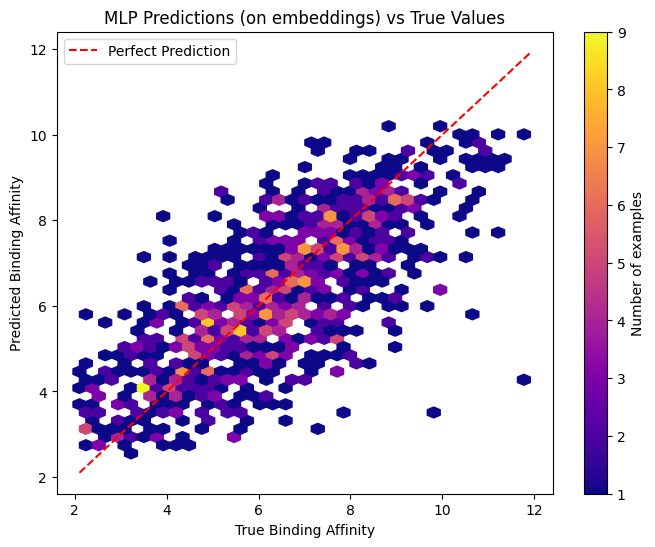

In [16]:
# Create hexbin plot
plt.figure(figsize=(8, 6))
hb = plt.hexbin(y_true_list, y_pred_list, gridsize=35, cmap='plasma', mincnt=1)

# Add a colorbar to indicate density
cb = plt.colorbar(hb)
cb.set_label('Number of examples')

# Add labels and title
plt.xlabel("True Binding Affinity")
plt.ylabel("Predicted Binding Affinity")
plt.title("MLP Predictions (on embeddings) vs True Values")

# Add a diagonal line y = x to show the ideal prediction
min_val = min(min(y_true_list), min(y_pred_list))
max_val = max(max(y_true_list), max(y_pred_list))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', label='Perfect Prediction')

# Add legend
plt.legend()

# Show the plot
plt.show()